# Equality Ratios

The following notebook explores limitations in our analysis by noting how many feederlines run through every census tract. Additionally, it attempts to weight census-level host capacity by the percentage of each racial group in that census tract. 

## Setup

In [1]:
# import necessary libraries
import geopandas as gpd
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt

os.environ['PROJ_LIB'] = '/opt/anaconda3/share/proj'

In [2]:
# read in data
cal = gpd.read_file("../../../../../../capstone/electrigrid/data/dis_adv_comm/calenviroscreen50_D_12226.gdb")
pge = gpd.read_parquet("../../../../../../capstone/electrigrid/data/census_hosting_capacity/pge_census_map_new.parquet")
sdge = gpd.read_parquet("../../../../../../capstone/electrigrid/data/census_hosting_capacity/sdge_census_map_new.parquet")
sce = gpd.read_parquet("../../../../../../capstone/electrigrid/data/census_hosting_capacity/sce_census_map_new.parquet")

In [3]:
# keep only necessary columns
cal_clean = cal[['tract', 'ZIP', 'Population', 'CIscore', 'AirOzone','AirPM25','Education', 'LinguisticIso', 'Poverty', 'Unemployment', 'White_Pct',
       'Hispanic_Pct', 'Black_Pct', 'NatAmeri_Pct', 'Asian_Pct','OtherMulti_Pct']]

# concatenate the three utilities into one
utility = pd.concat([pge, sdge, sce])

# change tract column in `cal` to object
cal_clean['tract'] = cal_clean['tract'].astype('string')

# strip decimal (.0) at the end) -- ONLY RUN ONCE
cal_clean['tract'] = cal_clean['tract'].str[:-2] 

# add start 0 back in -- ONLY RUN ONCE
cal_clean['tract'] = '0' + cal_clean['tract']

stats = pd.merge(cal_clean, utility, left_on = "tract", right_on = "GEOID")

/tmp/ipykernel_1939122/3741532960.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cal_clean['tract'] = cal_clean['tract'].astype('string')
/tmp/ipykernel_1939122/3741532960.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cal_clean['tract'] = cal_clean['tract'].str[:-2]
/tmp/ipykernel_1939122/3741532960.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https

In [4]:
stats.head(2)

,tract,ZIP,Population,CIscore,AirOzone,AirPM25,Education,LinguisticIso,Poverty,Unemployment,...,GEOID,geometry,avg_DER_remain_pv_hh,avg_DER_remain_pv_opflex_hh,avg_DER_remain_generation_hh,avg_DER_remain_generation_opflex_hh,avg_DER_total_generation_hh,avg_DER_remain_load_hh,avg_DER_total_pv_hh,zillow_tract_hh_count
0,06001400100,94720,3094.0,9.786846,0.029251,7.135387,0.901639,0.683891,8.780488,5.454545,...,06001400100,"POLYGON ((-197333.073 -12225.563, -197310.342 ...",0.152437,0.075076,0.124346,0.040838,5.294694,2.053362,5.322785,394.0
1,06001400200,94618,2093.0,7.181343,0.028516,7.348713,3.567251,0.813008,9.603440,5.249110,...,06001400200,"POLYGON ((-198413.266 -16953.512, -198395.570 ...",0.412830,0.508324,0.329433,0.406497,5.319559,2.112841,5.402956,403.0


In [5]:
# convert into geodataframe
stats_geo = stats.set_geometry('geometry')

## Explore Feederlines by Census Tract

To do so, I have to load in each of the original utility data frames and geospatially join with census tract geometries (which exist in `stats`)


In [6]:
pge_raw = gpd.read_parquet("~/../../capstone/electrigrid/data/utilities/pge_updated/pge.parquet").to_crs(epsg=3310)

In [7]:
sce_raw = gpd.read_parquet("~/../../capstone/electrigrid/data/utilities/sce_circuits/ica_circuit_segments.parquet").to_crs(epsg=3310)

In [8]:
sdge_raw = gpd.read_file("~/../../capstone/electrigrid/data/utilities/sandiego_grid/gen_cap_lines_sdge.geojson").to_crs(epsg=3310)

In [9]:
# m for merged
pge_raw_m = gpd.sjoin(pge_raw, stats_geo)

In [10]:
# view number of feeders in each census tract for PGE
feeders_pge = pge_raw_m.groupby('GEOID')['FeederId'].count()

feeders_pge.describe()

count    3175.000000
mean      624.257323
std       815.064155
min         1.000000
25%       208.000000
50%       362.000000
75%       709.500000
max      9627.000000
Name: FeederId, dtype: float64

In [11]:
sce_raw_m = gpd.sjoin(sce_raw, stats_geo)

feeders_sce = sce_raw_m.groupby('GEOID')['circuit_name'].count()

feeders_sce.describe()

count    3050.000000
mean      242.280656
std       357.891998
min         1.000000
25%        97.000000
50%       161.000000
75%       264.000000
max      6612.000000
Name: circuit_name, dtype: float64

In [12]:
sdge_raw_m = gpd.sjoin(sdge_raw, stats_geo)

feeders_sdge = sdge_raw_m.groupby('GEOID')['CIRCUIT_NAME'].count()

feeders_sdge.describe()

count     791.000000
mean      234.295828
std       253.538065
min         2.000000
25%       106.000000
50%       168.000000
75%       257.500000
max      2718.000000
Name: CIRCUIT_NAME, dtype: float64

### Feederline Conclusion

There are a lot of feederlines in each census tract! This affects the granularity of our analysis significantly.

## Weighting by % Race/Ethnic Group

### Incoporating Census Tract Size (# of households)

In [13]:
# set option to see all data frame columns
pd.set_option('display.max_columns', None)

In [14]:
stats.head(2)

,tract,ZIP,Population,CIscore,AirOzone,AirPM25,Education,LinguisticIso,Poverty,Unemployment,White_Pct,Hispanic_Pct,Black_Pct,NatAmeri_Pct,Asian_Pct,OtherMulti_Pct,GEOID,geometry,avg_DER_remain_pv_hh,avg_DER_remain_pv_opflex_hh,avg_DER_remain_generation_hh,avg_DER_remain_generation_opflex_hh,avg_DER_total_generation_hh,avg_DER_remain_load_hh,avg_DER_total_pv_hh,zillow_tract_hh_count
0,06001400100,94720,3094.0,9.786846,0.029251,7.135387,0.901639,0.683891,8.780488,5.454545,68.10,6.46,4.43,0.00,14.93,6.08,06001400100,"POLYGON ((-197333.073 -12225.563, -197310.342 ...",0.152437,0.075076,0.124346,0.040838,5.294694,2.053362,5.322785,394.0
1,06001400200,94618,2093.0,7.181343,0.028516,7.348713,3.567251,0.813008,9.603440,5.249110,67.27,9.36,2.05,0.67,12.23,8.41,06001400200,"POLYGON ((-198413.266 -16953.512, -198395.570 ...",0.412830,0.508324,0.329433,0.406497,5.319559,2.112841,5.402956,403.0


In [15]:
# list of columns
groups = ['White_Pct', 'Hispanic_Pct', 'Black_Pct', 'NatAmeri_Pct', 'Asian_Pct', 'OtherMulti_Pct']

for group in groups:
    
    # divide by 100 b/c % are being stored as whole numbers currently
    stats[group] = stats[group]/100

**Explanation of ratio being used**

Observations are at the census-tract level.

1. We calculate the proportion of each census tracts generation that is attributed to the demographic group, and sum across all census tracts.
2. We find the total capacity of all census tracts.
3. Calculate the population share of the demographic group across all census tracts.
4. Divide the total weighted generation of each demographic group by total capacity, then divide that by the share of the population that that demographic group represents.

Ultimately, we find: the proportion of the group's capacity relative to all capacity / the group's pop share

In [16]:
# create empty list to append to
ratios = []

# list of columns
groups = ['White_Pct', 'Hispanic_Pct', 'Black_Pct', 'NatAmeri_Pct', 'Asian_Pct', 'OtherMulti_Pct']

for group in groups:
    
    # Weighted capacity share vs population share
    stats['weighted_cap'] = stats['avg_DER_remain_generation_hh'] * stats[group]  # e.g. pct_group = 0.30
    
    # Sum across all census tracts
    group_weighted = stats['weighted_cap'].sum()
    
    # Total generation across all census tracts
    total_cap = stats['avg_DER_remain_generation_hh'].sum()
  
    # calculate pop share
    group_population_share = (stats[group] * stats['zillow_tract_hh_count']).sum() / stats['zillow_tract_hh_count'].sum()
    
    # use pop share to determine equity ratio
    equity_ratio = (group_weighted / total_cap) / group_population_share
    
    # append to list
    ratios.append(equity_ratio)

In [17]:
# create table to view results
d = {
    "Group": groups,
    "Equity ratio w/ tract size": ratios}

table = pd.DataFrame(d)
table

,Group,Equity ratio w/ tract size
0,White_Pct,1.007409
1,Hispanic_Pct,0.945945
2,Black_Pct,1.058691
3,NatAmeri_Pct,1.022778
4,Asian_Pct,1.031280
5,OtherMulti_Pct,1.022815


A ratio of 1.0 = proportional access, >1 = over-represented in capacity, <1 = under-represented.

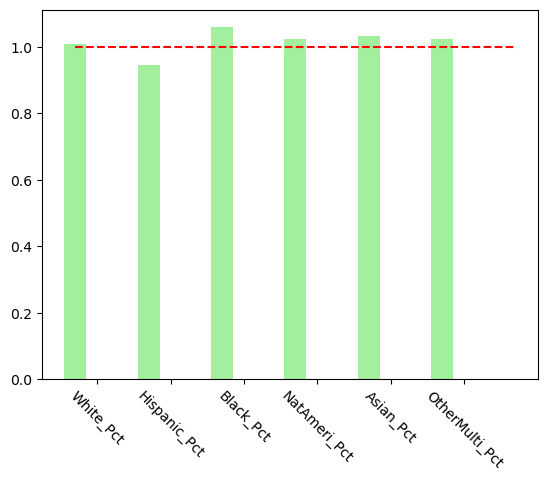

In [20]:
# create barplot to visualize

# set bar width
barWidth = 0.3

# x position
pos_size = np.arange(len(table['Equity ratio w/ tract size']))
 
# create bars
plt.bar(pos_size, table['Equity ratio w/ tract size'], width = barWidth, color = '#a2f09e')

# set x labels and rotate
plt.xticks([r + barWidth for r in range(len(table['Equity ratio w/ tract size']))], table['Group'], rotation = -45)

# plot line at 1
plt.hlines(y = 1, xmin = 0, xmax = 6, color = "red", linestyles = 'dashed')
 
plt.show()

These ratios, particularly with green columns (generation capacity relative to population share) answers the question: **is this group's access to capacity proportional to their population share?**

We can interpret these ratios as:

- A ratio of 1.0 = proportional access
- A ratio of >1 = over-represented in capacity
- A ratio of <1 = under-represented.

It appears that hispanic is the only group which is under-represented in capacity.

In [21]:
from itertools import product

# create empty list to append to
ratios = []

# list of columns
groups = ['White_Pct', 'Hispanic_Pct', 'Black_Pct', 'NatAmeri_Pct', 'Asian_Pct', 'OtherMulti_Pct']
grid_vars = ['avg_DER_remain_pv_hh', 'avg_DER_remain_generation_hh', 'avg_DER_total_generation_hh', 'avg_DER_remain_load_hh', 'avg_DER_total_pv_hh'] 

for group, grid_var in product(groups, grid_vars):
    stats['weighted_cap'] = stats[grid_var] * stats[group]
    group_weighted = stats['weighted_cap'].sum()
    total_cap = stats[grid_var].sum()
    group_population_share = (stats[group] * stats['zillow_tract_hh_count']).sum() / stats['zillow_tract_hh_count'].sum()
    equity_ratio = (group_weighted / total_cap) / group_population_share
    ratios.append({'group': group, 'grid_var': grid_var, 'equity_ratio': equity_ratio})

df_ratios = pd.DataFrame(ratios).pivot(index='group', columns='grid_var', values='equity_ratio')

In [22]:
df_ratios

grid_var,avg_DER_remain_generation_hh,avg_DER_remain_load_hh,avg_DER_remain_pv_hh,avg_DER_total_generation_hh,avg_DER_total_pv_hh
group,,,,,
Asian_Pct,1.031280,0.974158,1.019331,0.886775,0.890747
Black_Pct,1.058691,1.026889,1.065782,0.927620,0.934536
Hispanic_Pct,0.945945,0.948958,0.960034,0.982704,0.985935
NatAmeri_Pct,1.022778,1.159024,1.107212,1.110548,1.111008
OtherMulti_Pct,1.022815,1.013997,1.011537,1.019066,1.016250
White_Pct,1.007409,1.042777,1.003502,1.075056,1.069798


In [ ]:
# Save as CSV for import into R for better vizualization tools
# df_ratios.to_csv("ratios.csv")

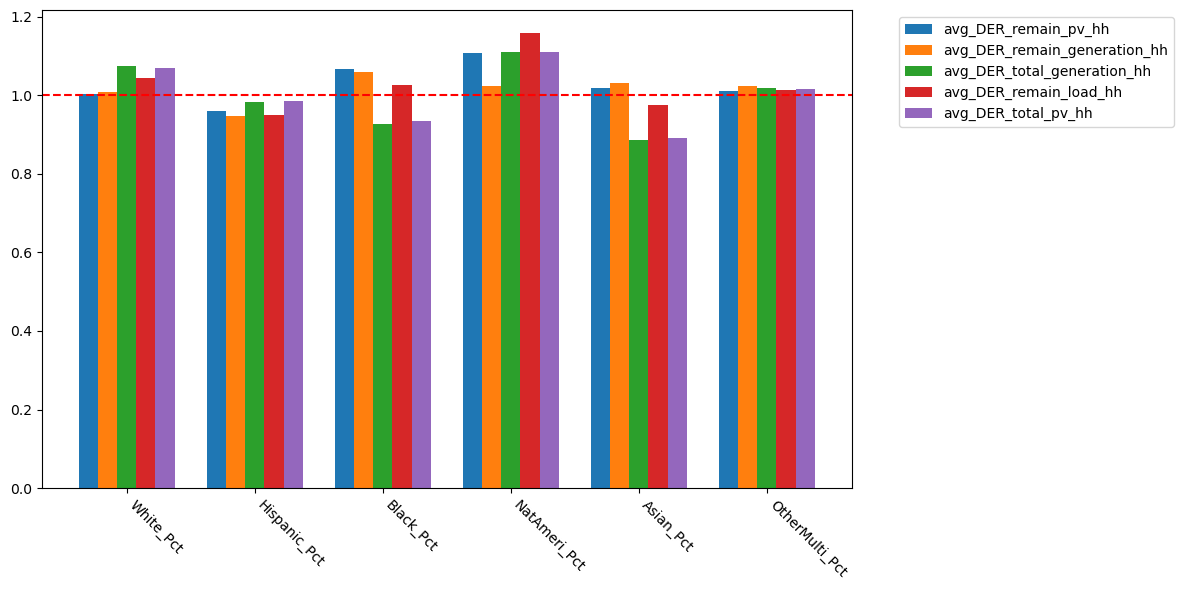

In [23]:
import matplotlib.pyplot as plt
import numpy as np

barWidth = 0.15
x = np.arange(len(groups))

fig, ax = plt.subplots(figsize=(12, 6))

for i, grid_var in enumerate(grid_vars):
    vals = [df_ratios.loc[group, grid_var] for group in groups]
    ax.bar(x + i * barWidth, vals, width=barWidth, label=grid_var)

ax.set_xticks(x + barWidth * (len(grid_vars) - 1) / 2)
ax.set_xticklabels(groups, rotation=-45, ha='left')
ax.axhline(y=1, color='red', linestyle='dashed')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Other potential methods

Borrowing from [Tong et al.](https://www.pnas.org/doi/10.1073/pnas.2023554118) which uses **disparity ratios** in their analysis. This is defined as:

"EUI [energy use intensity] disparity ratios by race are computed as the ratio of EUI in the top 20% most racially diverse block groups (>80th percentile of non-White population percentage) versus the 20% least racially diverse block groups. "

They used this to capture "annual EUI disparities by income and then by race within the lowest-income block groups to further unpack the racial effect from income." This allowed them to explore differences within racial groups *witin* income groups. They level of granularity were block groups.

#### Some of their results (for easy reference): 

"Fig. 1A demonstrates structural income–race inequality patterns, wherein highest-income quintile block groups are majority White (>50% White population), while the lowest-income quintile block groups have racial minorities (non-White) ranging from 16 to ∼95% (60% on average) in St. Paul. Fig. 1A shows distinct differences across income strata by racial structure. In terms of energy use, lowest-income groups have 24 to 45% lower consumption per household (SI Appendix, Table S3), although they have 27% higher EUI (Fig. 1B). Furthermore, a statistically significant racial effect is seen in St. Paul within all except the highest-income stratum (Fig. 1B), wherein an increase in non-White population percentage is significantly correlated with higher EUI. The impact of race may not be significant at the highest-income stratum because that stratum is majority White (i.e., very little racial diversity)."